# Information Visualization I 
## School of Information, University of Michigan

## Week 3: 
- Perception / Cognition

## Assignment Overview
### This assignment's objectives include:

- Review, refect, and apply the concepts of the perception pipeline. Justify how different encodings impact the effectiveness of a visualization depending on the human perception process.

!["Drawing"](/voc/data/preattentive_resized.png)

<p style="text-align: center;"> Preattentive Processing </p>

- Recreate visualizations and propose new and alternative visualizations using [Altair](https://altair-viz.github.io/) 

### The total score of this assignment will be 100 points consisting of:
- Case study reflection: America's Favorite 'Star Wars' Movies (And Least Favorite Characters) (25 points)
- Altair programming exercise (75 points)

### Resources:
- Article by [FiveThirtyEight](https://fivethirtyeight.com) available  [online](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/) (Hickey, 2014)  
- Datasets from FiveThirtyEight, we have downloaded a subset of this data in the folder [./assets](assets)
    - The original dataset can be found at [FiveThirtyEight Star Wars Survey](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)
    

### Important notes:
1) There will be a couple of places where the numbers you get when you select rows may be a little different than 538, but the percents should still work (e.g., 828 instead of 834). You'll see this in our examples. If you can somehow get the data to match exactly, that's great too.

2) A lot of this assignment will be based on building "compound" charts. Using the wrong strategy will mean that you are spending a lot of time "cleaning up" charts. We strongly suggest reading through (and understanding) the Altair documentation [on this](https://altair-viz.github.io/user_guide/compound_charts.html).

3) Grading for this assignment is entirely done by a human grader. They will be running tests on the functions we ask you to create. This means there is no autograding (submitting through the autograder will result in an error). You are expected to test and validate your own code. 

4) Keep your notebooks clean and readable. If your code is highly messy or inefficient you will get a deduction.

5) Follow the instructions for submission on Coursera. You will be providing us a generated link to a read-only version of your notebook and a PDF. When turning in your PDF, please use the File -> Print -> Save as PDF option ***from your browser***. Do ***not*** use the File->Download as->PDF option. Complete instructions for this are under Resources in the Coursera page for this class. If you're having trouble with printing, take a look at [this video](https://youtu.be/PiO-K7AoWjk).

## Part 1. Perception and Cognition (25 points)
Read the article ["America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters),"](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/) and answer the following questions:


### 1.1 List the different data types in the following visualizations and their encodings (10 points)
Look at the following visualizations. For each, list the variable, their type, and the encoding used. 

!["How rate visualization"](/voc/data/how_rate_resized.png)
!["Have seen visualization"](/voc/data/have_seen_resized.png)

Use the following table for each variable (indicate which vis each came from):
* variable name, variable type (e.g., ordinal, nominal, etc.), variable encoding (e.g., color, x-position, etc.)

For example, if you [look at this visualization](https://altair-viz.github.io/gallery/scatter_tooltips.html) one row in our table below would be: Horsepower, quantitative, x-position.

_1.1 Answer_

*Use as many rows as you need*

How People Rate the 'Star Wars' Movies

| Variable name| Variable Type (Ordinal/Nominal/Quantitative) | Variable encoding (color, x-position, etc.) |
| --- | --- | --- |
|  Film Title | Nominal | y-position |
|  Rating Category (which third) | Ordinal | Color |
|  % of respondents | Quantitative | x-position (length of bar) |


Which 'Star Wars' Movies Have You Seen?

| Variable name| Variable Type (Ordinal/Nominal/Quantitative) | Variable encoding (color, x-position, etc.) |
| --- | --- | --- |
|  Film Title | Nominal | y-position |
|  % Seen | Quantitative | x-position (length of bar) |
|  Movie Label Text (percentage number) | Quantitative (derived) | Text label overlay |




### 1.2 A Pie Chart Version (15 points)


!["Drawing"](/voc/data/have_seen_resized.png)

Your colleague is arguing that the chart above could be made more *effective* by using one or more pie charts. In what situations are they right? In what situations would they be wrong? If it helps makes your case, feel free to create a picture (hand drawn is fine) and load it into the notebook.

The colleague would be right only if the goal were to show proportional composition of a whole, i.e. if the six movies together represented mutually exclusive categories summing to 100%. For example, if the question were “Of all movies seen, what proportion of total viewings does each film represent?” then a pie chart could show how much each movie contributes to total viewership share. In that case, each slice would represent a part of one complete whole (100%), and a pie chart could make sense visually.

The colleague would be wrong in this actual case because each percentage is independent — it represents the share of people who have seen each movie, not slices of one total 100%. Respondents can (and usually do) see multiple movies. Therefore, the percentages add up to more than 100%, and each bar is not a part of the same whole. A pie chart would falsely imply that the categories are mutually exclusive. In situations where bar charts excel at showing individual category magnitudes, and provide easy side-by-side comparison — these situations bar is better than pie so our colleague would be wrong

## Part 2. Altair programming exercise (75 points)
We have provided you with some code and parts of the article [America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters)](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/). This article is based on the dataset:

1. [StarWars](data/StarWars.csv) Created by FiveThirtyEight based on a survey ran through SurveyMonkey Audience, surveying 1,186 respondents from June 3 to 6 2014. Available [online] (https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)

To earn points for this assignment, you must:

- Recreate the visualizations in the article (replace the images in the article with a code cell that creates a visualization). We provide one example. Each visualization is worth 10 points (40 points/ 10 each x 4 total ).

    - _Partial credit can be granted for each visualization (up to 5 points) if you provide the grammar of graphics description of the visualization without a functional Altair implementation_


- Propose two variants (a "good one" and a "bad one") for a new visualization for the article. You'll be asked to justify why one is better than the other. We are specifically interested in your explanation of why the "good one" is more *effective* based on principles of perception/cognition. (35 points/ 20 points for the plots + 15 for justification)




In [1]:
import pandas as pd
import altair as alt
import numpy as np
import math
from mads.lib.path import assets

In [2]:
# enable correct rendering
alt.renderers.enable('mimetype')

RendererRegistry.enable('mimetype')

In [3]:
# uses intermediate json files to speed things up
alt.data_transformers.enable('json')

DataTransformerRegistry.enable('json')

In [4]:
def loadStarwarsData(filename='StarWars.csv'):
    
    # input: filename to original dataset (default StarWars.csv)
    # output: cleaned up dataframe with columns appropriately renamed
    
    filename = assets.find(filename)
    sw = pd.read_csv(filename, encoding='latin1')

    # Some format is needed for the survey dataframe, we provide the formatted dataset in a dataframe 
    sw = sw.rename(columns={'Have you seen any of the 6 films in the Star Wars franchise?':'seen_any_movie',
                            'Do you consider yourself to be a fan of the Star Wars film franchise?': 'fan',
                            'Which of the following Star Wars films have you seen? Please select all that apply.' : 'seen_EI',
                            'Unnamed: 4' : 'seen_EII',
                            'Unnamed: 5' : 'seen_EIII',
                            'Unnamed: 6' : 'seen_EIV',
                            'Unnamed: 7' : 'seen_EV',
                            'Unnamed: 8' : 'seen_EVI',
                            'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.' : 'rank_EI',
                            'Unnamed: 10' : 'rank_EII',
                            'Unnamed: 11' : 'rank_EIII',
                            'Unnamed: 12' : 'rank_EIV',
                            'Unnamed: 13' : 'rank_EV',
                            'Unnamed: 14' : 'rank_EVI',
                            'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.' : 'Han Solo',
                            'Unnamed: 16' : 'Luke Skywalker',
                            'Unnamed: 17' : 'Princess Leia Organa',
                            'Unnamed: 18' : 'Anakin Skywalker',
                            'Unnamed: 19' : 'Obi Wan Kenobi',
                            'Unnamed: 20' : 'Emperor Palpatine',
                            'Unnamed: 21' : 'Darth Vader',
                            'Unnamed: 22' : 'Lando Calrissian',
                            'Unnamed: 23' : 'Boba Fett',
                            'Unnamed: 24' : 'C-3P0',
                            'Unnamed: 25' : 'R2 D2',
                            'Unnamed: 26' : 'Jar Jar Binks',
                            'Unnamed: 27' : 'Padme Amidala',
                            'Unnamed: 28' : 'Yoda',
                           })
    sw = sw.drop([0])
    return(sw)

sw = loadStarwarsData()

In [5]:
# take a peak to look at the data
sw.sample(5)

,RespondentID,seen_any_movie,fan,seen_EI,seen_EII,seen_EIII,seen_EIV,seen_EV,seen_EVI,rank_EI,...,Yoda,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?æ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
933,3.289283e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,No,Female,30-44,"$25,000 - $49,999",Bachelor degree,West South Central
803,3.289664e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6,...,Very favorably,Greedo,Yes,Yes,No,Male,18-29,NaN,High school degree,South Atlantic
243,3.290916e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,Han,Yes,Yes,Yes,Male,45-60,NaN,Some college or Associate degree,Pacific
591,3.290158e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,2,...,Somewhat favorably,I don't understand this question,No,NaN,Yes,Female,18-29,"$100,000 - $149,999",Bachelor degree,Pacific
137,3.291391e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,No,Female,30-44,"$25,000 - $49,999",Some college or Associate degree,South Atlantic


# America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters)

_Original article available at [FiveThirtyEight](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/)_

By [Walt Hickey](https://fivethirtyeight.com/contributors/walt-hickey/)

Filed under [Movies](https://fivethirtyeight.com/tag/movies/)

Get the data on [GitHub](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)

This week, I caught a sneak peek [of the X-Wing fighter](http://www.wired.com/2014/07/star-wars-episode-vii-x-wing/) from the new “Star Wars” films in production. The forthcoming movies — and the middling response to the most recent trilogy — provide a perfect excuse to examine some questions I’ve long wanted answers to: How many people are “Star Wars” fans? Does the rest of America realize that “The Empire Strikes Back” is clearly the best of the bunch? Which characters are most well-liked and most hated? And who shot first, Han Solo or Greedo?

We ran a poll through [SurveyMonkey Audience](https://www.surveymonkey.com/mp/audience/), surveying 1,186 respondents from June 3 to 6 (the [data](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey) is available [on GitHub](https://github.com/fivethirtyeight/data)). Seventy-nine percent of those respondents said they had watched at least one of the “Star Wars” films. This question, incidentally, had a substantial difference by gender: 85 percent of men have seen at least one “Star Wars” film compared to 72 percent of women. Of people who have seen a film, men were also more likely to consider themselves a fan of the franchise: 72 percent of men compared to 60 percent of women.

We then asked respondents which of the films they had seen. With 835 people responding, here’s the probability that someone has seen a given “Star Wars” film given that they have seen any Star Wars film:

!["Sol1"](/voc/data/have_seen_resized.png)

In [6]:
# We're going to fix the labels a bit so will create a mapping to the full names
# and have the full sort order
def genEpisodeNamesDF():
    # create the various mapping and order lists/dictionaries
    # return: list of episodes (in order), episode->name map, list of episode names (in order)
    episodes = ['EI', 'EII', 'EIII', 'EIV', 'EV', 'EVI']
    names = {
        'EI' : 'The Phantom Menace', 'EII' : 'Attack of the Clones', 'EIII' : 'Revenge of the Sith', 
        'EIV': 'A New Hope', 'EV': 'The Empire Strikes Back', 'EVI' : 'The Return of the Jedi'
    }

    # we're also going to use this order to sort, so names_l will now have our sort order
    return episodes, names, [names[ep] for ep in episodes]

episodes, namesDict, namesList = genEpisodeNamesDF()

In [7]:
# let's inspect what we've generated. These will be useful to you below
print("abbreviated list (sorted):\n  ",episodes)
print("\nmapping between abberviated names and full titles:\n  ",namesDict)
print("\nfull titles, sorted:\n  ",namesList)


abbreviated list (sorted):
   ['EI', 'EII', 'EIII', 'EIV', 'EV', 'EVI']

mapping between abberviated names and full titles:
   {'EI': 'The Phantom Menace', 'EII': 'Attack of the Clones', 'EIII': 'Revenge of the Sith', 'EIV': 'A New Hope', 'EV': 'The Empire Strikes Back', 'EVI': 'The Return of the Jedi'}

full titles, sorted:
   ['The Phantom Menace', 'Attack of the Clones', 'Revenge of the Sith', 'A New Hope', 'The Empire Strikes Back', 'The Return of the Jedi']


In [8]:
# let's do some data pre-processing... recall that sw (star wars) has everything

def getSeenAtLeastOneDF(indf, eps):
    # input: indf the data file as formatted above
    # input: eps a list of episodes (movies)

    # returns a substet of the dataset
    
    # We want to only use those people who have seen at least one movie, let's get the people, toss NAs
    # and get the total count

    # find people who have at least on of the columns (seen_*) not NaN
    salo = indf.dropna(subset=['seen_' + ep for ep in eps],how='all')
    
    return(salo)


In [9]:
seenAtLeastOneDF = getSeenAtLeastOneDF(sw, episodes)
print("total who have seen at least one: ", len(seenAtLeastOneDF),"\nSample:")
display(seenAtLeastOneDF.sample(5))

total who have seen at least one:  835 
Sample:


,RespondentID,seen_any_movie,fan,seen_EI,seen_EII,seen_EIII,seen_EIV,seen_EV,seen_EVI,rank_EI,...,Yoda,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?æ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
1181,3.288390e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,Han,No,NaN,No,Female,45-60,"$0 - $24,999",Some college or Associate degree,Pacific
969,3.288729e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,NaN,NaN,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,...,Somewhat favorably,Han,No,NaN,Yes,Female,45-60,"$50,000 - $99,999",Bachelor degree,South Atlantic
968,3.288740e+09,Yes,No,NaN,Star Wars: Episode II Attack of the Clones,NaN,NaN,NaN,NaN,2,...,Very favorably,I don't understand this question,No,NaN,No,Female,18-29,NaN,Some college or Associate degree,Pacific
20,3.292562e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6,...,Very favorably,Greedo,No,NaN,Yes,Male,18-29,"$50,000 - $99,999",Some college or Associate degree,West North Central
806,3.289652e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,2,...,Very favorably,Greedo,Yes,No,Yes,Female,45-60,"$100,000 - $149,999",Graduate degree,Pacific


In [10]:
# for each movie, we're going to calculate the percents and generate a new data frame

def genSeenPercentDf(inpf, names=namesDict, names_l=namesList):
    # input: inpf - an input frame of the form output by getSeenAtLeastOneDF()
    # input: names - a dictionary of abbreviations to names
    # input: names_l - a list of all the movies in series order
    
    total = len(inpf)
    percs = []

    # loop over each column and calculate the number of people who have seen the movie
    # specifically, filter out the people who are *NaN* for a specific episode (e.g., ep_EII), count them
    # and divide by the percent
    for seen_ep in ['seen_' + ep for ep in episodes]:
        perc = len(inpf[~ pd.isna(inpf[seen_ep])]) / total
        percs.append(perc)

    # at this point percs is holding our percentages

    # now we're going use a trick to make tuples--pairing names with percents--using "zip" and then make a dataframe
    tuples = list(zip([names[ep] for ep in episodes],percs))
    seen_per_df = pd.DataFrame(tuples, columns = ['Name', 'Percentage'])
    return(seen_per_df)

In [11]:
seenPerMovieDF = genSeenPercentDf(seenAtLeastOneDF)

In [12]:
# let's see what's inside
seenPerMovieDF

,Name,Percentage
0,The Phantom Menace,0.805988
1,Attack of the Clones,0.683832
2,Revenge of the Sith,0.658683
3,A New Hope,0.726946
4,The Empire Strikes Back,0.907784
5,The Return of the Jedi,0.883832


In [13]:
def genPercentVis(indf, names_l=namesList):
    # input: indf, the dataframe as seen_per_df
    # input: names_l - a list of all the movies in series order (default namesList)
    # output: simple altair bar chart
    
    # ok, time to make the chart... let's make a bar chart (use mark_bar)
    bars = alt.Chart(indf).mark_bar(size=20).encode(
        # encode x as the percent, and hide the axis
        x=alt.X(
            'Percentage',
            axis=None),
        y=alt.Y(
            # encode y using the name, use the movie name to label the axis, sort using the names_l
            'Name:N',
             axis=alt.Axis(tickCount=5, title=''),
             # we give the sorting order to avoid alphabetical order
             sort=names_l
        )
    )

    # at this point we don't really have a great plot (it's missing the annotations, titles, etc.)
    return(bars)

seenPerMovieVis = genPercentVis(seenPerMovieDF)

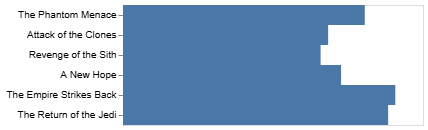

In [14]:
# display it
seenPerMovieVis

In [15]:
def augmentPercentVis(base):
    # input: base (the base vis, i.e., bars as above)
    # we're going to overlay the text with the percentages, so let's make another visualization
    # that's just text labels


    text = base.mark_text(
        align='left',
        baseline='middle',
        dx=3  # Nudges text to right so it doesn't appear on top of the bar
    ).encode(
        # we'll use the percentage as the text
        text=alt.Text('Percentage:Q',format='.0%')
    )

    # finally, we're going to combine the bars and the text and do some styling
    seen_movies = (text + base).configure_mark(
        # we don't love the blue
        color='#008fd5'
    ).configure_view(
        # we don't want a stroke around the bars
        strokeWidth=0
    ).configure_scale(
        # add some padding
        bandPaddingInner=0.2
    ).properties(
        # set the dimensions of the visualization
        width=500,
        height=180
    ).properties(
        # add a title
        title="Which 'Star Wars' Movies Have you Seen?"
    )

    return(seen_movies)

# note that we are NOT formatting this in the Five Thirty Eight Style yet... we'll leave that to you to figure out

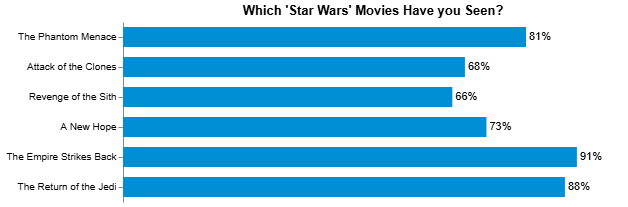

In [16]:
# let's see it
augmentPercentVis(seenPerMovieVis)

So we can see that “Star Wars: Episode V — The Empire Strikes Back” is the film seen by the most number of people, followed by “Star Wars: Episode VI — Return of the Jedi.” Appallingly, more people reported seeing “Star Wars: Episode I — The Phantom Menace” than the original “Star Wars” (renamed “Star Wars: Episode IV — A New Hope”).

So, which movie is the best? We asked the subset of 471 respondents who indicated they have seen every “Star Wars” film to rank them from best to worst. From that question, we calculated the share of respondents who rated each film as their favorite.

!["Sol1"](/voc/data/best_movie_article_resized.png)


** Homework note: Click [here](/voc/data/best_movie.png) to see a version of this plot generated in Altair.

### 2.1 What's the best 'Star Wars' movie? Recreate the above image using altair (10 Points)

Recreate the image above using Altair. Match the "538" style as best you can (hint: look at the altair lab at the start of the semester). We expect you to *at least* match the [our version](best_movie.png) of the chart that was created in Altair.

In [20]:
# Recreate this image using Altair
# match the "538 style" as best you can (hint: look at the altair lab at the start of the semester)

def genBestVis(inpf,eps, names=namesDict, names_l=namesList):
    # input: inpf, the star wars dataset
    # input: eps, the list of episodes
    # input: names - a dictionary of abbreviations to names (default: namesDict)
    # input: names_l - a list of all the movies in series order (default: namesList)
    # output: the Altair visualization as described above
    # --- subset: respondents who have seen all six films ---
    seen_all = inpf[inpf[[f'seen_{e}' for e in eps]].notna().all(axis=1)].copy()
    total_seen_all = len(seen_all)

    # --- coerce rank columns to numeric (critical fix) ---
    rank_cols = [f'rank_{e}' for e in eps]
    seen_all[rank_cols] = seen_all[rank_cols].apply(pd.to_numeric, errors='coerce')

    # favorite counts & percentages (rank == 1)
    rows = []
    for e in eps:
        cnt = (seen_all[f'rank_{e}'] == 1).sum()
        rows.append({
            'Episode': e,
            'Name': names[e],
            'Count': int(cnt),
            'Percentage': (cnt / total_seen_all) if total_seen_all else 0.0
        })
    fav_df = pd.DataFrame(rows)

    # chart (538-ish)
    base = alt.Chart(fav_df).encode(
        y=alt.Y('Name:N', sort=names_l, axis=alt.Axis(title='', labelFontSize=12)),
        x=alt.X('Percentage:Q', axis=None)
    )
    bars = base.mark_bar(size=22, color='#008fd5')
    labels = base.mark_text(align='left', baseline='middle', dx=6
                           ).encode(text=alt.Text('Percentage:Q', format='.0%'))

    title_text = "What's the Best 'Star Wars' Movie?"
    subtitle_text = f"Of {total_seen_all} respondents who have seen all six films"

    chart = (bars + labels).properties(
        width=600, height=220,
        title={'text': title_text, 'subtitle': subtitle_text}
    ).configure_view(strokeWidth=0
    ).configure_axis(grid=False, labelColor='#555'
    ).configure_title(anchor='start', fontSize=20, subtitleFontSize=13)

    return chart

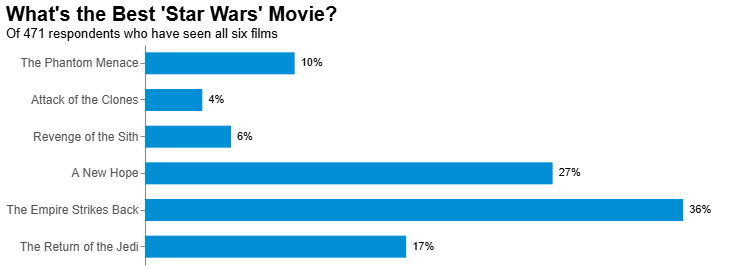

In [21]:
# test your code
genBestVis(sw,episodes)

## Make sure to *style* your visualization to match the original the best you can

We can also drill down and find out, generally, how people rate the films. Overall, fans broke into two camps: those who preferred the original three movies and those who preferred the three prequels. People who said “The Empire Strikes Back” was their favorite were also likely to rate “A New Hope” and “Return of the Jedi” higher as well. Those who rated “The Phantom Menace” as the best film were more likely to rate prequels higher.

This chart shows how often each film was rated in the top third (best or second-best), the middle third (third or fourth) or the bottom third (second-worst or worst). It’s a more nuanced take on the series:

!["Sol1"](/voc/data/how_rate_resized.png)

** Homework note: Click [here](/voc/data/people_rate.png) to see a version of this plot generated in Altair.

### 2.2 How people rate the 'Star Wars' movie? Recreate the above image using altair (10 Points)

In [24]:
# Recreate this image using altair here (10 POINTS)

def genRateVis(inpf,eps, names=namesDict, names_l=namesList):
    # input: inpf, the star wars dataset
    # input: eps, the list of episodes
    # input: names - a dictionary of abbreviations to names (default: namesDict)
    # input: names_l - a list of all the movies in series order (default: namesList)
    # output: the Altair visualization as described above
    
     # respondents who have seen all six
    seen_all = inpf[inpf[[f'seen_{e}' for e in eps]].notna().all(axis=1)].copy()
    total = len(seen_all)

    # coerce ranks
    rank_cols = [f'rank_{e}' for e in eps]
    seen_all[rank_cols] = seen_all[rank_cols].apply(pd.to_numeric, errors='coerce')

    # tidy: percentages in each third
    rows = []
    for e in eps:
        r = seen_all[f'rank_{e}']
        rows += [
            {'Name': names[e], 'Tier': 'Top third',    'Percentage': (r.isin([1,2])).mean()},
            {'Name': names[e], 'Tier': 'Middle third', 'Percentage': (r.isin([3,4])).mean()},
            {'Name': names[e], 'Tier': 'Bottom third', 'Percentage': (r.isin([5,6])).mean()},
        ]
    tidy = pd.DataFrame(rows)

    # color mapping
    domain = ['Top third','Middle third','Bottom third']
    range_  = ['#7bc96f','#1f77b4','#e45756']

    base = alt.Chart(tidy).encode(
        y=alt.Y('Name:N', sort=names_l, axis=alt.Axis(title='', labelFontSize=12)),
        x=alt.X('Percentage:Q', axis=None),
        color=alt.Color('Tier:N', scale=alt.Scale(domain=domain, range=range_), legend=None)
    )

    bars   = base.mark_bar(size=18)
    labels = base.mark_text(align='left', baseline='middle', dx=6
                           ).encode(text=alt.Text('Percentage:Q', format='.0%'))

    # set width/height on INNER spec, then facet
    inner = (bars + labels).properties(width=180, height=180)

    title_text = "How People Rate the 'Star Wars' Movies"
    subtitle_text = (f"How often each film was rated in the top, middle and bottom third\n"
                     f"(by {total} respondents who have seen all six films)")

    chart = inner.facet(
        column=alt.Column('Tier:N', sort=domain,
                          header=alt.Header(labelFontSize=12, title=None))
    ).properties(
        title={'text': title_text, 'subtitle': subtitle_text}
    ).configure_view(
        strokeWidth=0
    ).configure_axis(
        grid=False, labelColor='#555'
    ).configure_title(
        anchor='start', fontSize=20, subtitleFontSize=13
    ).resolve_scale(
        y='shared', x='independent'
    )

    return chart

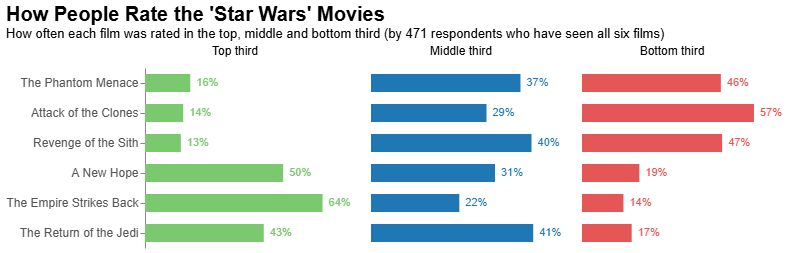

In [25]:
# let's check our solution
genRateVis(sw,episodes)

Finally, we took a boilerplate format used by political favorability polls — “Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her” — and asked respondents to rate characters in the series.

!["Sol1"](/voc/data/char_ranking_resized.png)


** Homework note. Here's an example solution generated in Altair:
!["Sol1"](/voc/data/people_rate_s.png)

Be careful here in what you're dividing by to get the totals for each character.

### 2.3 Star Wars' Characters Favorability Ratings. Recreate the above image using altair (10 Points)

In [26]:
# Recreate this image using altair here (10 POINTS)

def genFavorabilityVis(inpf):
    # input: inpf, the star wars dataset (as defined at top of file)
    # output: the Altair visualization as described above
    
    # ---- characters present in the formatted dataset ----
    char_cols = [
        'Luke Skywalker','Han Solo','Princess Leia Organa','Obi Wan Kenobi','Yoda',
        'R2 D2','C-3P0','Anakin Skywalker','Darth Vader','Lando Calrissian',
        'Padme Amidala','Boba Fett','Emperor Palpatine','Jar Jar Binks'
    ]
    # keep only the columns that exist (defensive)
    char_cols = [c for c in char_cols if c in inpf.columns]
    if not char_cols:
        raise ValueError("No character columns found in dataframe.")

    # ---- tidy to long form ----
    long = (
        inpf[char_cols]
        .melt(var_name='Character', value_name='Response')
        .dropna(subset=['Response'])
    )

    # ---- bucket responses into four categories (robust to slight wording diffs) ----
    def bucket(s):
        t = str(s).strip().lower()
        if 'unfamiliar' in t:
            return 'Unfamiliar'
        if 'neither' in t or 'neutral' in t:
            return 'Neutral'
        if 'unfavor' in t:
            return 'Unfavorable'
        if 'favor' in t:
            return 'Favorable'
        return None

    long['Tier'] = long['Response'].map(bucket)
    long = long.dropna(subset=['Tier'])

    # ---- compute percentages per character ----
    totals = long.groupby('Character').size().rename('Total')
    counts = long.groupby(['Character','Tier']).size().rename('Count').reset_index()
    tidy = counts.merge(totals, on='Character')
    tidy['Percentage'] = tidy['Count'] / tidy['Total']

    # order characters by Favorable percentage (desc), as in 538 figure
    fav_order = (
        tidy[tidy['Tier'] == 'Favorable']
        .sort_values('Percentage', ascending=False)['Character']
        .tolist()
    )

    # ---- color palette & facet order ----
    tier_order = ['Favorable', 'Neutral', 'Unfavorable', 'Unfamiliar']
    tier_colors = ['#7bc96f', '#1f77b4', '#e45756', '#9b9b9b']  # green, blue, red, gray

    base = alt.Chart(tidy).encode(
        y=alt.Y('Character:N', sort=fav_order, axis=alt.Axis(title='', labelFontSize=12)),
        x=alt.X('Percentage:Q', axis=None),
        color=alt.Color('Tier:N',
                        scale=alt.Scale(domain=tier_order, range=tier_colors),
                        legend=None)
    )

    bars = base.mark_bar(size=18)
    labels = base.mark_text(align='left', baseline='middle', dx=6
                           ).encode(text=alt.Text('Percentage:Q', format='.0%'))

    inner = (bars + labels).properties(width=150, height=360)

    title_text = "'Star Wars' Characters Favorability Ratings"
    subtitle_text = "By respondents (percent of each character’s ratings in each bucket)"

    chart = inner.facet(
        column=alt.Column('Tier:N', sort=tier_order,
                          header=alt.Header(labelFontSize=12, title=None))
    ).properties(
        title={'text': title_text, 'subtitle': subtitle_text}
    ).configure_view(
        strokeWidth=0
    ).configure_axis(
        grid=False, labelColor='#555'
    ).configure_title(
        anchor='start', fontSize=20, subtitleFontSize=13
    ).resolve_scale(
        y='shared', x='independent'
    )

    return chart

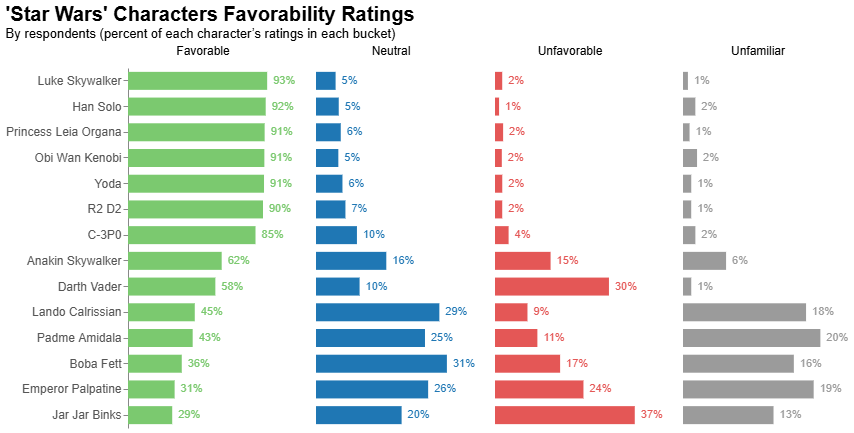

In [27]:
# let's test the solution
genFavorabilityVis(sw)

!["Sol1"](/voc/data/shot_first_article_resized.png)


** Homework note: Click [here](/voc/data/shot_first.png) to see a version of this plot generated in Altair. You may find that you don't get 834 rows (as 538 did) but the percents should still work.

### 2.4 Who shot first? Recreate the above image using altair (10 Points)

In [30]:
# Recreate this image using altair here (10 POINTS)

def genFirstShotVis(inpf):
    # input: inpf, the star wars dataset
    # output: the Altair visualization as described above
    
    # --- get valid responses ---
    q_col = 'Which character shot first?'  # column name in dataset (check exact match)
    if q_col not in inpf.columns:
        raise ValueError("Column not found in dataset")

    df = inpf[[q_col]].dropna()
    total = len(df)

    # --- normalize answer text ---
    def clean(x):
        x = str(x).strip().lower()
        if 'han' in x:
            return 'Han'
        elif 'greedo' in x:
            return 'Greedo'
        elif 'understand' in x:
            return "I don't understand this question"
        return None

    df['Response'] = df[q_col].map(clean)
    df = df.dropna(subset=['Response'])

    # --- count & compute percentage ---
    counts = (
        df.groupby('Response').size().reset_index(name='Count')
        .assign(Percentage=lambda d: d['Count'] / total)
    )

    # order for chart
    order = ["Han", "Greedo", "I don't understand this question"]

    # --- Altair chart ---
    base = alt.Chart(counts).encode(
        y=alt.Y('Response:N', sort=order, axis=alt.Axis(title='', labelFontSize=12)),
        x=alt.X('Percentage:Q', axis=None)
    )

    bars = base.mark_bar(size=25, color='#008fd5')
    labels = base.mark_text(
        align='left', baseline='middle', dx=6
    ).encode(text=alt.Text('Percentage:Q', format='.0%'))

    title_text = "Who Shot First?"
    subtitle_text = f"According to {total} respondents"

    chart = (bars + labels).properties(
        width=500, height=150,
        title={'text': title_text, 'subtitle': subtitle_text}
    ).configure_view(
        strokeWidth=0
    ).configure_axis(
        grid=False, labelColor='#555'
    ).configure_title(
        anchor='start', fontSize=20, subtitleFontSize=13
    )

    return chart

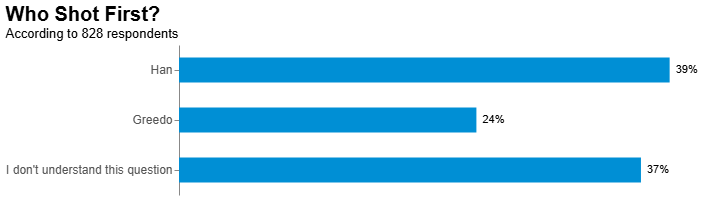

In [31]:
# test our solution
genFirstShotVis(sw)

### 2.5 Make your own (35 points total - 20 for implementation, 15 for justification)

Reading through the article, identify some aspect of the story that would benefit from an extra visualization (you can imagine extending the article if it helps). We would like for you to create two versions of this hypothetical visualization.  You should be able to convincingly argue that one visualization is better than the other.

Note: The two visualizations should use different marks and at least some of the encodings should be different. If you're struggling with coming up with two really different representations, your visualization may simply be too simple. Try to add additional columns/comparisons. 

In [32]:
# The article keeps hinting at a generational split (original trilogy people vs prequel people), but it never shows it directly, so let’s visualize that.
# Good version

# ---- helper to compute tidy percentages per age group ----
def _trilogy_by_age_tidy(inpf):
    # columns present in the course-cleaned version
    eps = ['EI','EII','EIII','EIV','EV','EVI']
    rank_cols = [f'rank_{e}' for e in eps]
    seen_cols = [f'seen_{e}' for e in eps]

    df = inpf.copy()

    # keep those who have seen ALL six
    seen_all = df[df[seen_cols].notna().all(axis=1)].copy()

    # coerce ranks to numeric
    seen_all[rank_cols] = seen_all[rank_cols].apply(pd.to_numeric, errors='coerce')

    # find an age column robustly
    age_col = None
    for c in seen_all.columns:
        if 'age' in str(c).lower():
            age_col = c
            break
    if age_col is None:
        raise ValueError("Couldn't locate an age column (looked for 'age' in column names).")

    # identify favorite episode (rank == 1; ties are rare—argmin works)
    fav_col = seen_all[rank_cols].idxmin(axis=1)
    prequel_set = {'rank_EI','rank_EII','rank_EIII'}
    seen_all['Trilogy'] = np.where(fav_col.isin(prequel_set), 'Prequel', 'Original')

    # tidy counts -> percents
    tidy = (seen_all
            .dropna(subset=[age_col, 'Trilogy'])
            .groupby([age_col, 'Trilogy'])
            .size()
            .rename('n')
            .reset_index())

    totals = tidy.groupby(age_col)['n'].sum().rename('total')
    tidy = tidy.merge(totals, on=age_col)
    tidy['pct'] = tidy['n'] / tidy['total']

    # human ordering for ages (extract leading number if present)
    def _age_key(a):
        import re
        s = str(a)
        m = re.search(r'\d+', s)
        return int(m.group()) if m else 10_000
    age_order = sorted(tidy[age_col].unique().tolist(), key=_age_key)

    # rename to canonical names Altair will use
    tidy = tidy.rename(columns={age_col: 'Age', 'pct': 'Percentage'})
    tidy['Trilogy'] = pd.Categorical(tidy['Trilogy'], categories=['Prequel','Original'], ordered=True)

    return tidy, age_order

# ---- GOOD: Dumbbell (rule + points + labels) ----
def genTrilogyByAge_GOOD(inpf):
    tidy, age_order = _trilogy_by_age_tidy(inpf)

    # for the connecting rule we need min & max per Age
    mm = (tidy.groupby('Age')['Percentage']
                .agg(minpct='min', maxpct='max')
                .reset_index())

    rule = alt.Chart(mm).mark_rule().encode(
        y=alt.Y('Age:N', sort=age_order, axis=alt.Axis(title='', labelFontSize=12)),
        x=alt.X('minpct:Q', title=None, axis=None),
        x2='maxpct:Q'
    )

    pts = alt.Chart(tidy).mark_point(filled=True, size=80).encode(
        y=alt.Y('Age:N', sort=age_order, axis=alt.Axis(title='', labelFontSize=12)),
        x=alt.X('Percentage:Q', axis=None),
        color=alt.Color('Trilogy:N', scale=alt.Scale(domain=['Prequel','Original'],
                                                    range=['#7bc96f','#1f77b4']),
                        legend=alt.Legend(orient='bottom'))
    )

    labels = alt.Chart(tidy).mark_text(align='left', baseline='middle', dx=6).encode(
        y=alt.Y('Age:N', sort=age_order),
        x='Percentage:Q',
        text=alt.Text('Percentage:Q', format='.0%'),
        color=alt.value('#444')
    )

    title = "Favorite Trilogy by Age Group"
    subtitle = "Share of respondents (who have seen all six) whose favorite is from each trilogy"

    return (rule + pts + labels).properties(
        width=560, height=280,
        title={'text': title, 'subtitle': subtitle}
    ).configure_view(strokeWidth=0).configure_axis(grid=False)


In [33]:
# Bad version
# ---- BAD: 100% stacked bars (hard cross-age comparisons) ----
def genTrilogyByAge_BAD(inpf):
    tidy, age_order = _trilogy_by_age_tidy(inpf)

    bars = alt.Chart(tidy).mark_bar().encode(
        y=alt.Y('Age:N', sort=age_order, axis=alt.Axis(title='', labelFontSize=12)),
        x=alt.X('Percentage:Q', stack='normalize', axis=None),
        color=alt.Color('Trilogy:N', scale=alt.Scale(domain=['Prequel','Original'],
                                                    range=['#7bc96f','#1f77b4']),
                        legend=alt.Legend(orient='bottom'))
    )

    labels = alt.Chart(tidy).mark_text(dx=0, dy=0).encode(
        y=alt.Y('Age:N', sort=age_order),
        x=alt.X('Percentage:Q', stack='center'),
        text=alt.Text('Percentage:Q', format='.0%'),
        color=alt.value('white')
    )

    title = "Favorite Trilogy by Age Group (100% Stacked)"
    subtitle = "Harder to compare one category across ages due to lack of a shared baseline"

    return (bars + labels).properties(
        width=560, height=280,
        title={'text': title, 'subtitle': subtitle}
    ).configure_view(strokeWidth=0).configure_axis(grid=False)

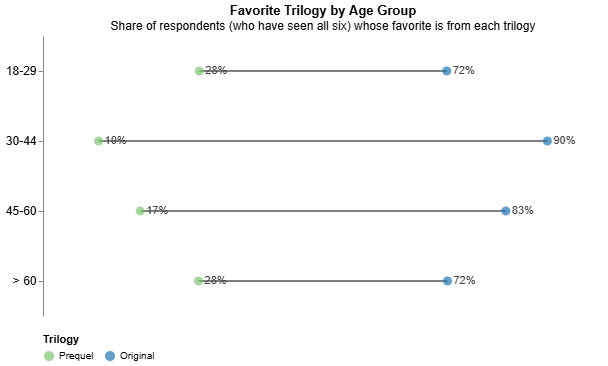

In [35]:
genTrilogyByAge_GOOD(sw)


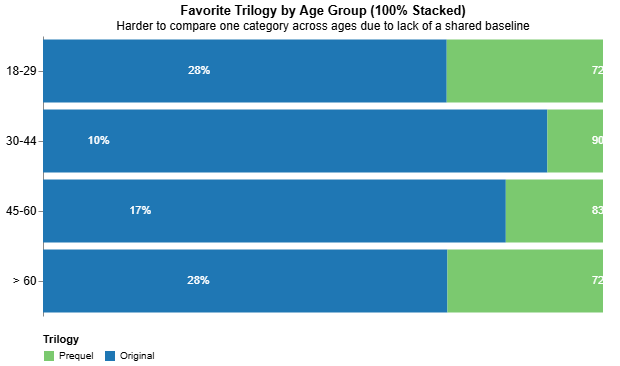

In [36]:
genTrilogyByAge_BAD(sw)

#### Justification
*Provide your justification here* to argue why your "better" version is actually better. Make sure to defend this based on expressiveness and effectiveness as well as perceptual arguments.

The good visualization uses a dumbbell dot plot with points and a connecting line.
- Marks: points (for Prequel/Original) + a line connecting them for each age group.
- Encodings: x = share of respondents (quantitative), y = age group (ordinal), color/legend = trilogy.
- Why it’s better: Both series share a common baseline (0–100%) on the x-axis, so you can precisely compare across ages. The gap between ends directly encodes how polarized each age group is. Also, labels are placed on the points, minimizing eye travel and avoiding angle/area illusions.

The bad visualization uses 100% stacked bars.
- Marks: bars (stacked).
- Encodings: x = cumulative percentage, y = age group, fill = trilogy.
- Why it’s worse: Only the leftmost series shares the baseline; the right segment floats, so comparing the prequel share across ages is hard (no common baseline). It encourages a part-to-whole reading rather than the analytical task (comparing one category across groups). Moreover, interior labels are harder to scan; the viewer must decode both position and length inside a stack.

In sum, the dumbbell gives both series a common 0–100% baseline, so you can precisely compare changes in one category (e.g., “Prequel”) across ages and also see the gap between trilogies within each age (encoded by the rule length). The 100% stacked bars remove the common baseline for the second category, making cross-age comparisons of one segment much harder.